# Hospital Readmission Risk Prediction

**Goal:** predict whether a diabetic patient will be readmitted within 30 days of discharge.

This notebook walks through the full workflow with outputs. The reusable code lives in `src/`,
so the notebook stays short and readable, and the same code runs in scripts and tests.

1. Load data
2. Exploratory data analysis (EDA)
3. Data preparation and feature engineering
4. Why a patient-level split matters (leakage experiment)
5. Model comparison with grouped cross-validation
6. Final training and calibration
7. Test set evaluation
8. Model interpretation
9. Conclusions

In [1]:
import sys
from pathlib import Path

# Make the project root importable (the notebook lives in notebooks/)
sys.path.append(str(Path.cwd().parent))

import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate

from src import config
from src.data import download_data, load_raw, prepare_dataset, split_by_patient
from src.evaluate import capacity_table, plot_calibration, plot_permutation_importance, plot_roc_pr
from src.features import engineer_features
from src.train import SCORING, build_models, compare_models

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

## 1. Load data

In [2]:
download_data()
raw = load_raw()
print(f"Shape: {raw.shape}")
raw.head()

Data already exists: data/raw/diabetic_data.csv


Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Exploratory data analysis

### 2.1 Target distribution

,count,share
readmitted,,
NO,54864,0.539
>30,35545,0.349
<30,11357,0.112


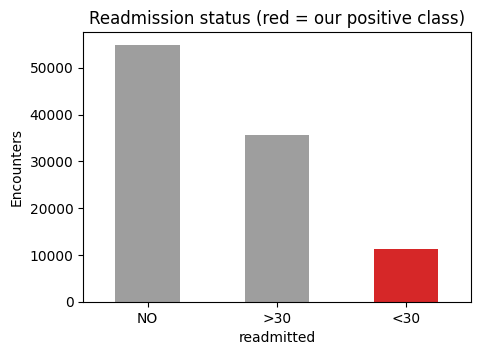

In [3]:
counts = raw["readmitted"].value_counts()
share = raw["readmitted"].value_counts(normalize=True).round(3)
display(pd.DataFrame({"count": counts, "share": share}))

ax = counts.plot.bar(color=["#9e9e9e", "#9e9e9e", "#d62728"], figsize=(5, 3.5), rot=0)
ax.set_title("Readmission status (red = our positive class)")
ax.set_ylabel("Encounters")
plt.show()

**Observation:** only **11.2%** of encounters are readmitted within 30 days, so the data is imbalanced.
A model that always says "no" would already have ~89% accuracy, so accuracy is not useful here.
We use **ROC-AUC** (ranking), **PR-AUC** (focus on the rare class) and the **Brier score** (quality of probabilities).
Readmissions after more than 30 days (`>30`) are counted as negative, as in the clinical definition.

### 2.2 Several encounters per patient

In [4]:
encounters_per_patient = raw.groupby("patient_nbr").size()
print(f"Unique patients: {encounters_per_patient.size:,}")
print(f"Patients with more than one encounter: {(encounters_per_patient > 1).mean():.1%}")
print(f"Encounters that belong to repeat patients: "
      f"{encounters_per_patient[encounters_per_patient > 1].sum() / len(raw):.1%}")
encounters_per_patient.clip(upper=10).value_counts().sort_index().rename("patients").to_frame().T

Unique patients: 71,518
Patients with more than one encounter: 23.5%
Encounters that belong to repeat patients: 46.2%


,1,2,3,4,5,6,7,8,9,10
patients,54745,10434,3328,1421,717,346,207,111,70,139


**Observation:** 23.5% of patients have more than one encounter, and these repeat patients produce
**46% of all encounters**. A random row split would put many patients on both sides of the split.
This is why every split in this project is done **by patient** (section 4 tests how much this matters).

### 2.3 Missing values

In [5]:
missing = raw.isna().mean().sort_values(ascending=False)
missing[missing > 0].round(3).rename("missing_share").to_frame()

,missing_share
weight,0.969
medical_specialty,0.491
payer_code,0.396
race,0.022
diag_3,0.014
diag_2,0.004
diag_1,0.000


In [6]:
# "None" in lab columns means "test not performed", not missing
raw[["max_glu_serum", "A1Cresult"]].apply(lambda col: col.value_counts(normalize=True).round(3))

,max_glu_serum,A1Cresult
>200,0.015,NaN
>300,0.012,NaN
>7,NaN,0.037
>8,NaN,0.081
None,0.947,0.833
Norm,0.026,0.049


**Decisions:**
- `weight` (97% missing) → dropped.
- `payer_code` (40% missing, insurance type, not clinical) → dropped.
- `medical_specialty` (49% missing) → kept; missing becomes its own category, because a missing specialty can carry information.
- `"None"` in `max_glu_serum` / `A1Cresult` means **test not performed** (95% and 83% of rows). It is kept as a real category.
  pandas would read it as NaN by default, so `load_raw` uses `keep_default_na=False`.

### 2.4 Readmission rate by key variables

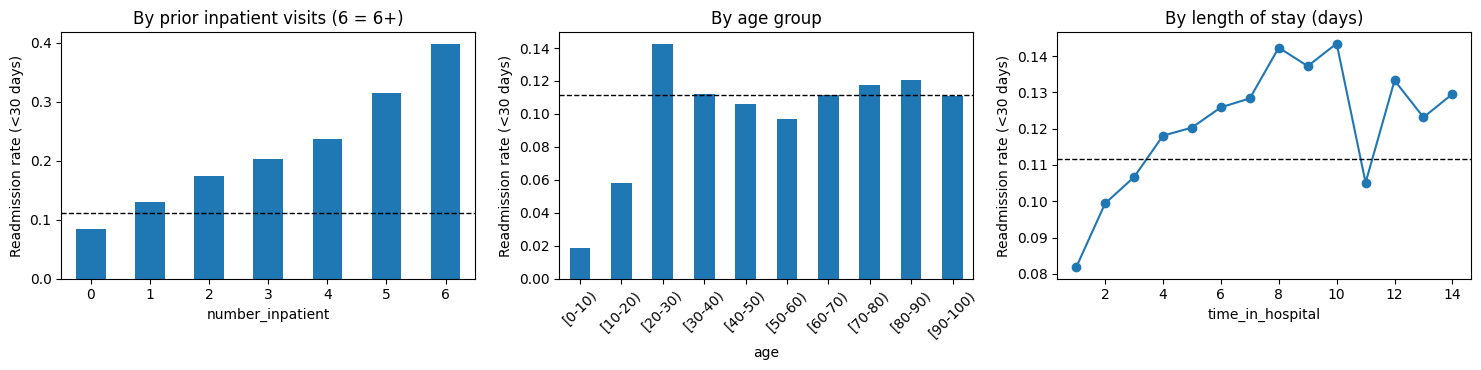

In [7]:
target = (raw["readmitted"] == "<30").astype(int)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

target.groupby(raw["number_inpatient"].clip(upper=6)).mean().plot.bar(ax=axes[0], rot=0)
axes[0].set_title("By prior inpatient visits (6 = 6+)")

target.groupby(raw["age"]).mean().plot.bar(ax=axes[1], rot=45)
axes[1].set_title("By age group")

target.groupby(raw["time_in_hospital"]).mean().plot(ax=axes[2], marker="o")
axes[2].set_title("By length of stay (days)")

for ax in axes:
    ax.axhline(target.mean(), color="k", linestyle="--", linewidth=1)
    ax.set_ylabel("Readmission rate (<30 days)")
fig.tight_layout()
plt.show()

In [8]:
# Discharge disposition: some codes mean death or hospice (they cannot be readmitted)
by_discharge = raw.groupby("discharge_disposition_id").agg(
    encounters=("readmitted", "size"),
    readmission_rate=("readmitted", lambda s: (s == "<30").mean()),
)
by_discharge.loc[sorted(config.EXCLUDED_DISCHARGE_IDS & set(by_discharge.index))].round(3)

,encounters,readmission_rate
discharge_disposition_id,,
11,1642,0.000
13,399,0.048
14,372,0.065
19,8,0.000
20,2,0.000


**Observations:**
- **Prior inpatient visits** is by far the strongest signal: the readmission rate rises from **8.4%** (no previous
  admission) to **~40%** (6+ previous admissions).
- Longer stays have a moderately higher rate (8% for 1 day, ~14% for 8–10 days).
- Age has a weak effect for adults (10–12%); children rarely return, but they are few.
- Discharge codes 11, 19, 20 (death) have a **0%** readmission rate, and hospice codes (13, 14) are also very low.
  These patients cannot really be readmitted, so we remove them instead of keeping them as "easy" negatives.

## 3. Data preparation and feature engineering

- Remove 3 rows with invalid gender and all encounters that end in death or hospice.
- Target: 1 if readmitted in less than 30 days.
- `patient_nbr` is kept aside as the **group** for splitting, not as a feature.

Feature engineering (`src/features.py`) is stateless and row-wise: age bracket → number, ICD-9 codes →
clinical groups, counts of active and changed medications, total prior visits. Imputation, scaling and
encoding happen inside the sklearn Pipeline.

In [9]:
X, y, groups = prepare_dataset(raw)
print(f"Rows removed: {len(raw) - len(X):,}")
print(f"Encounters: {len(X):,} | Patients: {groups.nunique():,} | Positive rate: {y.mean():.3f}")

features = engineer_features(X)
print(f"Features after engineering: {features.shape[1]}")
features.head()

Rows removed: 2,426
Encounters: 99,340 | Patients: 69,987 | Positive rate: 0.114


Features after engineering: 27


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_num,total_prior_visits,n_med_changes,n_meds_active,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,medical_specialty,max_glu_serum,A1Cresult,change,diabetesMed,insulin,metformin,diag_1_group,diag_2_group,diag_3_group
0,1,41,0,1,0,0,0,1,5.0,0,0,0,Caucasian,Female,6,25,1,Pediatrics-Endocrinology,None,None,No,No,No,No,Diabetes,Missing,Missing
1,3,59,0,18,0,0,0,9,15.0,0,1,1,Caucasian,Female,1,1,7,NaN,None,None,Ch,Yes,Up,No,Other,Diabetes,Other
2,2,11,5,13,2,0,1,6,25.0,3,0,1,AfricanAmerican,Female,1,1,7,NaN,None,None,No,Yes,No,No,Other,Diabetes,Other
3,2,44,1,16,0,0,0,7,35.0,0,1,1,Caucasian,Male,1,1,7,NaN,None,None,Ch,Yes,Up,No,Other,Diabetes,Circulatory
4,1,51,0,8,0,0,0,5,45.0,0,0,2,Caucasian,Male,1,1,7,NaN,None,None,Ch,Yes,Steady,No,Neoplasms,Neoplasms,Diabetes


In [10]:
# Readmission rate by primary diagnosis group
features.assign(target=y).groupby("diag_1_group")["target"].agg(["size", "mean"]) \
    .rename(columns={"size": "encounters", "mean": "readmission_rate"}) \
    .sort_values("readmission_rate", ascending=False).round(3)

,encounters,readmission_rate
diag_1_group,,
Missing,20,0.250
Diabetes,8661,0.131
Injury,6851,0.124
Circulatory,29680,0.117
Other,17793,0.117
Genitourinary,5002,0.110
Neoplasms,3131,0.109
Digestive,9333,0.108
Respiratory,13934,0.101


## 4. Why a patient-level split matters

The same patient can appear many times. With a normal row-level split, the model can "recognise" a
patient in the validation fold from their other encounters in the training fold. This experiment
compares both strategies on the training data with the same model.

In [11]:
X_train, X_test, y_train, y_test, groups_train = split_by_patient(X, y, groups, config.TEST_SIZE)
print(f"Train: {len(X_train):,} encounters | Test: {len(X_test):,} encounters")
print("Patient overlap between train and test:",
      len(set(groups_train) & set(groups.loc[X_test.index])))

Train: 79,567 encounters | Test: 19,773 encounters
Patient overlap between train and test: 0


In [12]:
model = build_models()["hist_gradient_boosting"]

row_cv = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)
row_scores = cross_validate(model, X_train, y_train, cv=row_cv, scoring=SCORING, n_jobs=-1)

grouped = compare_models({"hist_gradient_boosting": model}, X_train, y_train, groups_train)

leakage = pd.DataFrame({
    "row-level split (leaky)": [row_scores["test_roc_auc"].mean(), row_scores["test_pr_auc"].mean()],
    "patient-level split": [grouped["roc_auc_mean"].iloc[0], grouped["pr_auc_mean"].iloc[0]],
}, index=["ROC-AUC", "PR-AUC"]).round(4)
leakage

Cross-validating: hist_gradient_boosting


,row-level split (leaky),patient-level split
ROC-AUC,0.6713,0.6705
PR-AUC,0.2294,0.2297


**Result:** the two strategies give almost the **same** scores here (ROC-AUC 0.671 vs 0.671).

This is an honest and useful finding. Leakage from repeated patients is only large when the features
let the model **identify the patient** (for example very specific lab values, or many slices of the same
MRI scan in imaging). In this dataset the features are general (counts, categories), so the model cannot
memorise individual patients. The patient-level split is still the correct protocol: it costs nothing
and it guarantees that the reported score is what we would see on **new patients**.

## 5. Model comparison (5-fold patient-grouped CV)

Two candidates: a regularised Logistic Regression (simple, interpretable baseline) and
HistGradientBoosting (captures non-linear effects and interactions). We select by **PR-AUC**,
because the positive class is rare. The test set is not used here.

In [13]:
cv_results = compare_models(build_models(), X_train, y_train, groups_train)
config.REPORTS_DIR.mkdir(parents=True, exist_ok=True)
cv_results.to_csv(config.REPORTS_DIR / "cv_results.csv", index=False)
cv_results.round(4)

Cross-validating: logistic_regression


Cross-validating: hist_gradient_boosting


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std
1,hist_gradient_boosting,0.6705,0.0038,0.2297,0.0076,0.0961,0.0004
0,logistic_regression,0.6599,0.0039,0.2117,0.0079,0.0972,0.0004


**Result:** HistGradientBoosting is better on all three metrics (PR-AUC 0.230 vs 0.212, ROC-AUC 0.671 vs 0.660),
and the difference is larger than the fold-to-fold standard deviation. The gain over the linear model is small,
which tells us that most of the signal is simple (mainly prior visits and discharge type).
It is selected as the final model.

## 6. Final training and calibration

The training patients are split again: one part fits the model, the other part (different patients)
fits an **isotonic calibration** on top of the frozen model.

In [14]:
best_name = cv_results.iloc[0]["model"]
print(f"Selected model: {best_name}")

X_fit, X_calib, y_fit, y_calib, _ = split_by_patient(
    X_train, y_train, groups_train, config.CALIBRATION_SIZE
)
best_model = build_models()[best_name].fit(X_fit, y_fit)
calibrated_model = CalibratedClassifierCV(FrozenEstimator(best_model), method="isotonic")
calibrated_model.fit(X_calib, y_calib)

config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, config.MODELS_DIR / "model_uncalibrated.joblib")
joblib.dump(calibrated_model, config.MODELS_DIR / "model_calibrated.joblib");

Selected model: hist_gradient_boosting


## 7. Test set evaluation

The test patients were never used for training, model selection or calibration.

In [15]:
p_uncal = best_model.predict_proba(X_test)[:, 1]
p_cal = calibrated_model.predict_proba(X_test)[:, 1]

test_metrics = pd.Series({
    "base_rate": y_test.mean(),
    "roc_auc": roc_auc_score(y_test, p_cal),
    "pr_auc": average_precision_score(y_test, p_cal),
    "brier_uncalibrated": brier_score_loss(y_test, p_uncal),
    "brier_calibrated": brier_score_loss(y_test, p_cal),
    "brier_always_predict_base_rate": brier_score_loss(y_test, np.full(len(y_test), y_train.mean())),
}).round(4)
test_metrics.to_json(config.REPORTS_DIR / "test_metrics.json", indent=2)
test_metrics.to_frame("value")

,value
base_rate,0.1135
roc_auc,0.6718
pr_auc,0.2223
brier_uncalibrated,0.0955
brier_calibrated,0.0955
brier_always_predict_base_rate,0.1006


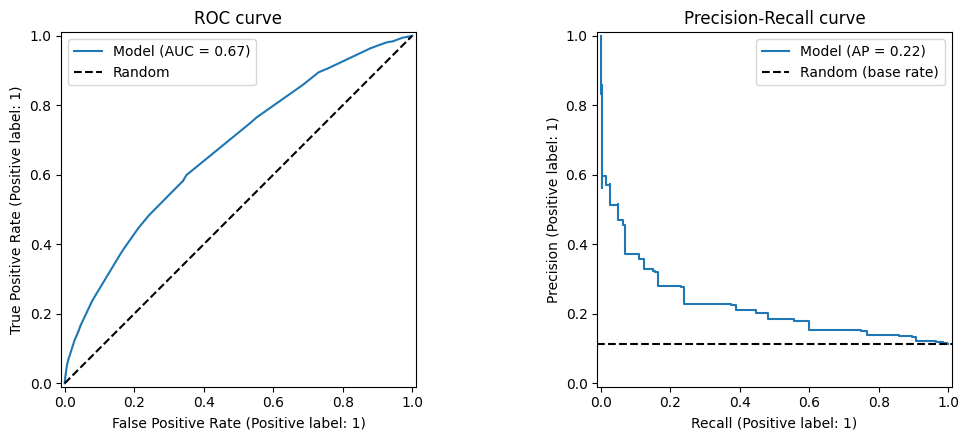

In [16]:
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plot_roc_pr(y_test, p_cal, config.FIGURES_DIR / "roc_pr_curves.png")
plt.show()

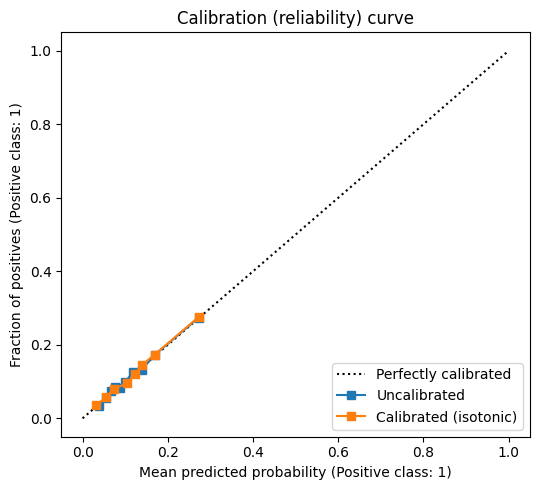

In [17]:
plot_calibration(
    y_test,
    {"Uncalibrated": p_uncal, "Calibrated (isotonic)": p_cal},
    config.FIGURES_DIR / "calibration_curve.png",
)
plt.show()

**Result:** the model is already **well calibrated** before isotonic calibration: both curves lie on the
diagonal, and the Brier score does not change (0.0955). This is expected because we trained on the natural
class distribution (no resampling, no class weights) with a log-loss objective.
Calibration is kept in the pipeline as a safety step, but here it did not add value; we report this openly.
The model's Brier score (0.0955) is better than always predicting the base rate (0.1006).

Note that predicted risks stay below ~0.30: the data does not contain features that make a patient
"almost certainly" readmitted.

### Follow-up program capacity analysis

A hospital cannot call every patient. If it contacts only the top-k% highest-risk patients,
how many of the real readmissions does it reach?

In [18]:
capacity = capacity_table(y_test, p_cal, config.CAPACITY_LEVELS)
capacity.to_csv(config.REPORTS_DIR / "capacity_table.csv", index=False)
capacity.round(3)

,contacted_share,precision,recall,lift
0,0.1,0.276,0.243,2.434
1,0.2,0.224,0.394,1.972
2,0.3,0.197,0.521,1.736


**Result:**
- Contacting the **top 10%** highest-risk patients reaches **24%** of all readmissions, with a precision of 28%
  (**2.4× better** than random selection).
- Contacting the **top 30%** reaches **52%** of readmissions.

This is the most practical way to present the model to a hospital: "with X% of the follow-up effort,
we reach Y% of the patients who will return".

## 8. Model interpretation (permutation importance)

How much PR-AUC drops when one raw input column is randomly shuffled.

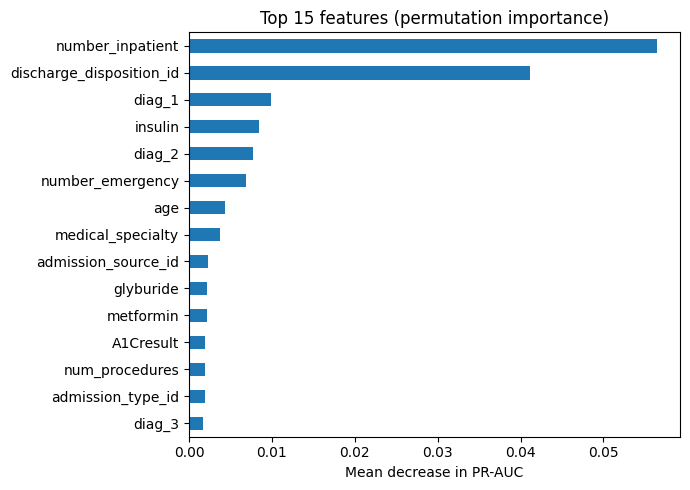

In [19]:
sample = X_test.sample(n=5000, random_state=config.RANDOM_STATE)
plot_permutation_importance(
    calibrated_model, sample, y_test.loc[sample.index],
    config.FIGURES_DIR / "permutation_importance.png",
)
plt.show()

**Observations:**
- `number_inpatient` (previous admissions) and `discharge_disposition_id` (where the patient goes after
  discharge, e.g. home vs. nursing facility) dominate, which matches the EDA and clinical intuition.
- Primary and secondary diagnoses, insulin use and emergency visits add smaller signal.
- Permutation importance shows association, **not causation**: it tells us what the model uses,
  not what causes readmission.

## 9. Conclusions

| | Value |
|---|---|
| Final model | HistGradientBoosting (+ isotonic calibration) |
| Test ROC-AUC | 0.672 |
| Test PR-AUC | 0.222 (base rate 0.114) |
| Test Brier score | 0.0955 (baseline 0.1006) |
| Top 10% contacted | 24% of readmissions reached, lift 2.4× |

**Key takeaways**
1. Readmission is hard to predict from administrative data alone. A ROC-AUC around 0.67 is in line with published
   results on this dataset; important factors (social support, adherence) are not in the data.
2. The model is still useful as a **ranking tool** for a follow-up program with limited capacity.
3. The patient-level split and the calibration check had little effect **on this dataset**, but they are part of
   a correct protocol, and the notebook shows it with evidence instead of assuming it.

**Next steps:** fairness check per subgroup (the data includes `race`), SHAP explanations per patient,
hyperparameter search, and temporal validation on newer data (ICD-10).